# Model Evaluation and Optimization

## 🔗 Builds on (AIAT 111–125)

AIAT 126 is the *graduation* project: it **assembles** what you already built across the diploma, it does not re-teach it. Open what you need:

- **AIAT 114 U2 — bias/variance and learning curves, for diagnosing *why* a model fails** → [`Course 04/unit2-regression-model-evaluation/examples/02_bias_variance_learning_curves.ipynb`](../../../Course%2004/unit2-regression-model-evaluation/examples/02_bias_variance_learning_curves.ipynb)
- **AIAT 114 U3 — the classification metrics and the confusion matrix** → [`Course 04/unit3-classification/examples/01_logistic_regression.ipynb`](../../../Course%2004/unit3-classification/examples/01_logistic_regression.ipynb)
- **AIAT 116 U4 — SHAP, for turning a failure case into an explanation** → [`Course 06/unit4-transparency-accountability/examples/01_shap_explanations.ipynb`](../../../Course%2006/unit4-transparency-accountability/examples/01_shap_explanations.ipynb)
- **AIAT 116 U2 — per-subgroup metrics: whose errors are they?** → [`Course 06/unit2-bias-fairness/examples/01_bias_detection.ipynb`](../../../Course%2006/unit2-bias-fairness/examples/01_bias_detection.ipynb)
- **AIAT 113 U5 — confidence intervals: is the improvement real or noise?** → [`Course 03/unit5-probability/examples/08_pvalues_confidence_intervals.ipynb`](../../../Course%2003/unit5-probability/examples/08_pvalues_confidence_intervals.ipynb)
- **AIAT 125 U5 — A/B and canary comparison, if you evaluate two versions live** → [`Course 11/unit5-pipelines-monitoring/examples/07_ab_testing_canary_deployment.ipynb`](../../../Course%2011/unit5-pipelines-monitoring/examples/07_ab_testing_canary_deployment.ipynb)

Record every artifact you reuse in **section 6, the Prior Work Inventory**, of [`TEMPLATES/project_proposal_template.md`](../../TEMPLATES/project_proposal_template.md). It is scored at gate 1 (criterion 1.7) and re-checked at the Unit 2 design review — it is this course's **CLO2** evidence, and the official AIAT 126 description requires it.

## 📚 Learning Objectives

By completing this notebook, you will:
- Conduct experiments and collect performance metrics
- Compare results with baseline or standard models
- Analyze failure cases and identify model weaknesses
- Visualize results using graphs, confusion matrices, and heat maps
- Run one refinement iteration (decision-threshold tuning) and measure whether it helped

## 🔗 Where this leads

**Used later in:** Course 12 — Unit 5, where these tables and figures become the report's results chapter.

---

This notebook covers practical activities from **Course 12, Unit 4**:
- Conducting experiments and collecting performance metrics
- Comparing results against a standard baseline model (logistic regression)
- Analyzing failure cases and identifying weaknesses in the model
- Visualizing results using graphs, confusion matrices, or heat maps
- Iteratively improving the model — demonstrated here with decision-threshold tuning

---

## Introduction

**Model Evaluation and Optimization** involves comprehensive analysis of model performance, identifying areas for improvement, and iteratively refining the model. Throughout this notebook we follow the discipline from Unit 3: models are compared and refined on the **validation** set, and the **test** set is used exactly once, at the very end.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Your own project dataset**, if you have one: put it at `data/my_project_data.csv` next to this
  notebook (same convention as Unit 3) and this evaluation workflow will run on it
- Otherwise a real named fallback — the 1912 Titanic passenger manifest, loaded with
  `load("titanic")` from the shared loader `tools/data.py` — a dataset name, not a path, so it
  resolves from any folder and on Google Colab

**Outputs:** What you'll see when you run the cells

- A three-way split, three candidate models compared on validation, confusion-matrix / ROC /
  precision-recall figures, a failure-case breakdown, one threshold-tuning iteration, and a
  single final measurement on the untouched test set.

---

---

## The sepsis model that watched 27,697 patients and missed two thirds of them

Epic's **Sepsis Model** is among the most widely deployed clinical prediction tools in the world. It runs inside the electronic health record used by hundreds of US hospitals, scoring inpatients continuously for the risk of sepsis — a condition where hours of delay cost lives. Epic's own documentation reported an AUC of **0.76 to 0.83**.

In 2021 a team at Michigan Medicine published a large **external** validation — the model measured by someone other than the vendor, on their own patients. **Wong et al., *JAMA Internal Medicine*, 2021** — **27,697 patients** across **38,455 hospitalizations**. The measured AUC was **0.63**. At the alert threshold in use, the model **failed to identify 1,709 of the 2,552 patients who developed sepsis — 67% of them** — while firing on **18% of all hospitalizations**, alerting clinicians about roughly one in five of everyone they admitted.

The vendor's number was not fabricated. It was measured somewhere else, on other patients, against a different definition of the outcome — and it did not transfer.

### What goes wrong without this

An evaluation that flatters the model is rarely a lie somebody tells. It is something that happens to you, and it happens whenever the number you report was produced using the same data that chose the model, the threshold and the features.

By the end of this notebook you will have watched it happen at capstone scale. The selected model reaches **F1 0.8125 on the validation set** and **0.7302 on the untouched test set** — an **eight-point** drop with no bug anywhere, caused entirely by the fact that validation was used both to pick the model *and* to pick the threshold.

Eight points is the difference between a system that looks ready and one that is not. In this course it is the gap between what you promised at gate 1 and what a reviewer measures at gate 4. The discipline below — three-way split, choose on validation, measure once on test — is what keeps that gap **visible** instead of hidden.

In [1]:
# Import everything used below: models, splitting, curve/matrix utilities and
# the four headline metrics — all imports in one place so every cell can use them.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                            roc_curve, auc, precision_recall_curve,
                            accuracy_score, precision_score, recall_score, f1_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic") — no path, from any folder
# -------------------------------------------------------------------------------------

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
# Load the project dataset (yours if present, a real named fallback otherwise) and make a
# THREE-way split so each job gets its own data: train to fit, validation to compare/refine,
# test for one final check (the discipline taught in Unit 3, notebook 01).
# WHY a real dataset: failure-case analysis is meaningless on invented rows — there is no
# such thing as a hard case when the labels came out of a formula.
PROJECT_DATA = Path("data/my_project_data.csv")      # <- your own dataset goes here

if PROJECT_DATA.exists():
    raw_data = pd.read_csv(PROJECT_DATA)
    data_source = f"YOUR project dataset ({PROJECT_DATA})"
    TARGET = "target"                                 # <- your label column
    feature_frame = pd.get_dummies(raw_data.drop(columns=[TARGET]), drop_first=True).fillna(0)
    y = raw_data[TARGET].to_numpy()
else:
    print(f"ℹ️  No file at {PROJECT_DATA} — using the real fallback dataset instead.")
    # load() asks the shared loader for the manifest by NAME, not by path, so this cell works
    # from any working directory and on Google Colab. It prints which copy it used — here,
    # always the whole 891-row file, so every metric below is the same for everyone.
    raw_data = load("titanic")
    data_source = "fallback: real Titanic passenger manifest (titanic.csv, 1912)"
    print()

    clean = raw_data.copy()
    clean["Age"] = clean["Age"].fillna(clean["Age"].median())        # 177 real gaps
    clean["Embarked"] = clean["Embarked"].fillna(clean["Embarked"].mode()[0])  # 2 real gaps
    feature_frame = pd.DataFrame({
        "pclass": clean["Pclass"],
        "is_female": (clean["Sex"] == "female").astype(int),
        "age": clean["Age"],
        "sibsp": clean["SibSp"],
        "parch": clean["Parch"],
        "fare": clean["Fare"],
        "family_size": clean["SibSp"] + clean["Parch"] + 1,
        "embarked_C": (clean["Embarked"] == "C").astype(int),
        "embarked_Q": (clean["Embarked"] == "Q").astype(int),
    })
    TARGET = "Survived"
    y = clean[TARGET].to_numpy()

# Standardize: logistic regression and the SVM below are distance/scale sensitive, and
# real columns come in wildly different units (fare 0-512 next to class 1-3).
X = StandardScaler().fit_transform(feature_frame.to_numpy(dtype=float))

# First carve off the untouched test set (20% of all data)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Then split what remains into training (60% overall) and validation (20% overall)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Source: {data_source}")
print(f"Features ({X.shape[1]}): {list(feature_frame.columns)}")
print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
print(f"Class balance overall: {np.bincount(y).tolist()}")
print(f"Majority-class baseline on validation: {max(np.bincount(y_val)) / len(y_val):.4f}")
print("📝 Models are compared and refined on the VALIDATION set")
print("📝 The TEST set is used exactly once, at the very end")

ℹ️  No file at data/my_project_data.csv — using the real fallback dataset instead.
titanic: full file, 891 rows.

Source: fallback: real Titanic passenger manifest (titanic.csv, 1912)
Features (9): ['pclass', 'is_female', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'embarked_C', 'embarked_Q']
Training: (534, 9), Validation: (178, 9), Test: (179, 9)
Class balance overall: [549, 342]
Majority-class baseline on validation: 0.6180
📝 Models are compared and refined on the VALIDATION set
📝 The TEST set is used exactly once, at the very end


## Part 1: Model Comparison - Multiple Algorithms

Compare different algorithms **on the validation set** to select the best
approach. Selecting on the test set would leak information and inflate the
final numbers — remember the rule from Unit 3: *use the test set ONLY for
final evaluation*.

In [3]:
# Train three candidate algorithms and compare them on the VALIDATION set —
# choosing a model is a modeling decision, so it must not touch the test set.
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

results = {}

print("=" * 60)
print("Model Comparison (validation set)")
print("=" * 60)

for name, model in models.items():
    # Fit on the training set only
    model.fit(X_train, y_train)

    # Predict labels and class-1 probabilities on the validation set
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]  # all three models support predict_proba

    # Record the four headline metrics plus raw predictions for later analysis
    results[name] = {
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'predictions': y_pred,
        'probabilities': y_proba
    }

    print(f"\n{name}:")
    print(f"  Accuracy:  {results[name]['accuracy']:.4f}")
    print(f"  Precision: {results[name]['precision']:.4f}")
    print(f"  Recall:    {results[name]['recall']:.4f}")
    print(f"  F1-Score:  {results[name]['f1']:.4f}")

# Select the winner by validation F1 (balances precision and recall)
best_model_name = max(results, key=lambda x: results[x]['f1'])
print(f"\n✅ Best Model (validation F1): {best_model_name} ({results[best_model_name]['f1']:.4f})")
print(f"   For scale, always predicting the majority class scores "
      f"{max(np.bincount(y_val)) / len(y_val):.4f} accuracy and 0.0000 F1 on the minority class.")

Model Comparison (validation set)

Logistic Regression:
  Accuracy:  0.7921
  Precision: 0.7460
  Recall:    0.6912
  F1-Score:  0.7176

Random Forest:
  Accuracy:  0.8202
  Precision: 0.7727
  Recall:    0.7500
  F1-Score:  0.7612

SVM:
  Accuracy:  0.8539
  Precision: 0.8750
  Recall:    0.7206
  F1-Score:  0.7903

✅ Best Model (validation F1): SVM (0.7903)
   For scale, always predicting the majority class scores 0.6180 accuracy and 0.0000 F1 on the minority class.


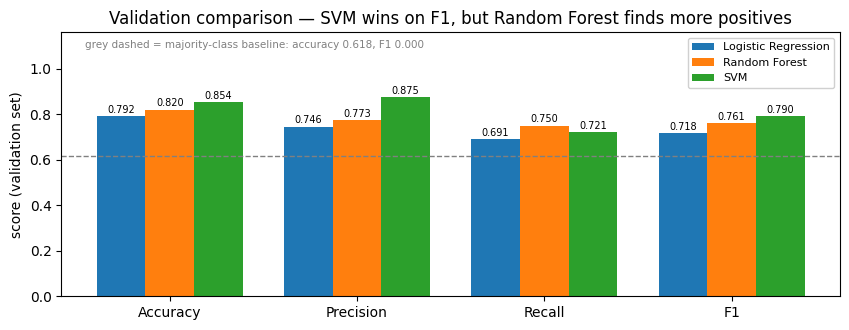

Highest recall:    Random Forest (0.7500)
Highest precision: SVM (0.8750)
Selected on F1:    SVM (precision 0.8750, recall 0.7206)

Reading: the selected model is the more CAUTIOUS one — it beats Random Forest on
false alarms, not on how many positives it finds.
Whether that trade is the right one is a question about consequences, not about F1 —
carry it into the Discuss section at the end of this notebook.


In [4]:
# WHAT: the twelve numbers just printed, drawn on one axis.
# WHY: a printed table tells you WHICH model won. One shared axis tells you HOW it won —
# and "how" is the part you have to defend at the gate review.
metric_names = ['accuracy', 'precision', 'recall', 'f1']
candidate_names = list(results)                 # same three models, same order as above
x = np.arange(len(metric_names))
bar_w = 0.26

fig, ax = plt.subplots(figsize=(8.6, 3.4))
for i, name in enumerate(candidate_names):
    scores = [results[name][m] for m in metric_names]
    bars = ax.bar(x + (i - 1) * bar_w, scores, bar_w, label=name)
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=1)   # print the value on each bar

# Reference line: the score you get for free by always predicting the majority class.
majority_acc = max(np.bincount(y_val)) / len(y_val)
ax.axhline(majority_acc, ls='--', c='grey', lw=1)
ax.text(-0.45, 1.09, f'grey dashed = majority-class baseline: accuracy {majority_acc:.3f}, F1 0.000',
        fontsize=7.5, color='grey')

# Build the title from the numbers themselves, so it stays true on your own dataset too.
top_recall = max(results, key=lambda n: results[n]['recall'])
top_prec = max(results, key=lambda n: results[n]['precision'])
title = f'Validation comparison — {best_model_name} wins on F1'
if top_recall != best_model_name:
    title += f', but {top_recall} finds more positives'
ax.set_title(title)
ax.set_xticks(x); ax.set_xticklabels([m.capitalize() for m in metric_names])
ax.set_ylim(0, 1.16); ax.set_ylabel('score (validation set)')
ax.legend(fontsize=8, loc='upper right', framealpha=.92)  # headroom, not on the bars; ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

# Read the figure in words — computed from the same numbers, not asserted in prose.
print(f"Highest recall:    {top_recall} ({results[top_recall]['recall']:.4f})")
print(f"Highest precision: {top_prec} ({results[top_prec]['precision']:.4f})")
print(f"Selected on F1:    {best_model_name} "
      f"(precision {results[best_model_name]['precision']:.4f}, "
      f"recall {results[best_model_name]['recall']:.4f})")
if top_recall != best_model_name:
    print(f"\nReading: the selected model is the more CAUTIOUS one — it beats {top_recall} on")
    print("false alarms, not on how many positives it finds.")
else:
    print("\nReading: the selected model leads on both halves of F1.")
print("Whether that trade is the right one is a question about consequences, not about F1 —")
print("carry it into the Discuss section at the end of this notebook.")

**Read the figure.** Four metrics, three models, one axis. The SVM's bar is tallest on accuracy (0.854), precision (0.875) and F1 (0.790) — but on **recall** it is *shorter* than the random forest's (0.721 against 0.750). The model this notebook selects is therefore the most **cautious** of the three: it wins by raising fewer false alarms, not by finding more survivors.

Every bar clears the grey majority-class line, so all three candidates are doing real work. But *"best on F1"* and *"best for the job"* are different claims, and only the second one requires an argument about consequences — which is why question 1 of the Discuss section asks who is entitled to make it.

## Part 2: Confusion Matrix and ROC Curve Visualization

Visualize the validation-set performance: a confusion-matrix heat map for the
selected model, ROC curves for every candidate, and the selected model's
precision-recall curve.

Confusion matrix (SVM, validation set):
True Negatives: 103, False Positives: 7
False Negatives: 19, True Positives: 49


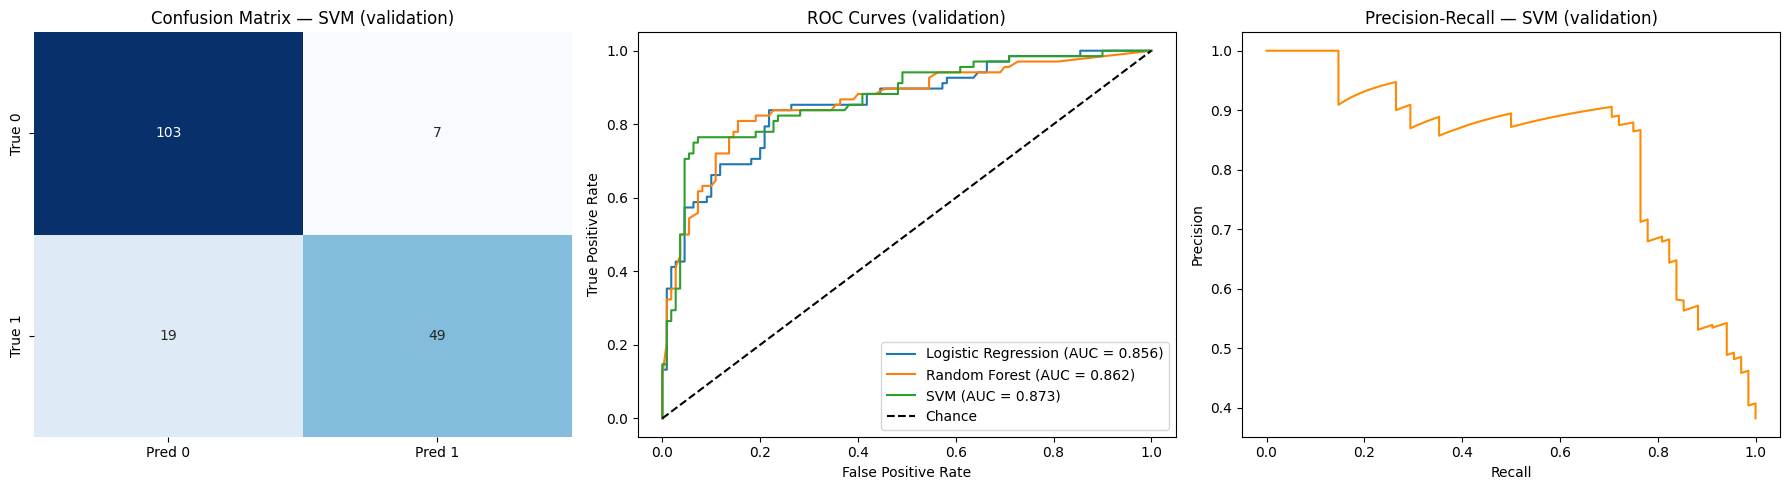


ROC AUC (SVM, validation): 0.8731


In [5]:
# Visualize validation performance: heat map of the winner's confusion matrix,
# ROC curves for all candidates, and the winner's precision-recall curve.
best_val_pred = results[best_model_name]['predictions']
cm = confusion_matrix(y_val, best_val_pred)

# Print the raw confusion-matrix cells for reference alongside the figure
print(f"Confusion matrix ({best_model_name}, validation set):")
print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: confusion-matrix heat map (counts annotated in each cell)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
axes[0].set_title(f'Confusion Matrix — {best_model_name} (validation)')

# Panel 2: ROC curves for ALL candidates on one axis (higher curve = better)
for name in results:
    fpr, tpr, _ = roc_curve(y_val, results[name]['probabilities'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', label='Chance')  # diagonal = random guessing
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves (validation)')
axes[1].legend()

# Panel 3: precision-recall curve for the selected model
prec, rec, _ = precision_recall_curve(y_val, results[best_model_name]['probabilities'])
axes[2].plot(rec, prec, color='darkorange')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title(f'Precision-Recall — {best_model_name} (validation)')

plt.tight_layout()
plt.show()

# Headline number: the selected model's ROC AUC on validation
best_fpr, best_tpr, _ = roc_curve(y_val, results[best_model_name]['probabilities'])
print(f"\nROC AUC ({best_model_name}, validation): {auc(best_fpr, best_tpr):.4f}")

## Part 3: Failure Case Analysis

Analyze where and why the selected model fails — on the **validation** set,
since failure analysis guides improvement and must not mine the test set.

On real data this is where a project earns its keep. The misclassified rows are real
records, so you can go back and *look at them*: which passengers did the model get wrong,
and is there a pattern (third-class women? men travelling alone with expensive tickets?)
that suggests a missing feature rather than a weak model?

In [6]:
# Break the validation errors into false positives / false negatives and look
# at the model's confidence on each: errors near 0.5 are 'unsure', errors far
# from 0.5 are confidently wrong and worth a closer look in your own project.
predictions = results[best_model_name]['predictions']
probs = results[best_model_name]['probabilities']

# Count the misclassified validation samples
misclassified_indices = np.where(predictions != y_val)[0]

print("=" * 60)
print("Failure Case Analysis (validation set)")
print("=" * 60)
print(f"Total validation samples: {len(y_val)}")
print(f"Correctly classified: {np.sum(predictions == y_val)}")
print(f"Misclassified: {len(misclassified_indices)} ({len(misclassified_indices)/len(y_val)*100:.2f}%)")

# Separate the two error types
false_positives = np.where((predictions == 1) & (y_val == 0))[0]
false_negatives = np.where((predictions == 0) & (y_val == 1))[0]

print(f"\nFalse Positives (Type I errors): {len(false_positives)}")
print(f"False Negatives (Type II errors): {len(false_negatives)}")

# Average predicted probability of class 1 for each error type
if len(false_positives) > 0:
    print(f"\nFalse Positive Analysis:")
    print(f"  Average confidence: {np.mean(probs[false_positives]):.4f}")
    print(f"  These samples were predicted as positive but are actually negative")

if len(false_negatives) > 0:
    print(f"\nFalse Negative Analysis:")
    print(f"  Average confidence: {np.mean(probs[false_negatives]):.4f}")
    print(f"  These samples were predicted as negative but are actually positive")

print("\n✅ Use failure case analysis to:")
print("  - Identify data quality issues")
print("  - Improve feature engineering")
print("  - Adjust class weights or thresholds")
print("  - Collect more training data for difficult cases")

Failure Case Analysis (validation set)
Total validation samples: 178
Correctly classified: 152
Misclassified: 26 (14.61%)

False Positives (Type I errors): 7
False Negatives (Type II errors): 19

False Positive Analysis:
  Average confidence: 0.7773
  These samples were predicted as positive but are actually negative

False Negative Analysis:
  Average confidence: 0.2166
  These samples were predicted as negative but are actually positive

✅ Use failure case analysis to:
  - Identify data quality issues
  - Improve feature engineering
  - Adjust class weights or thresholds
  - Collect more training data for difficult cases


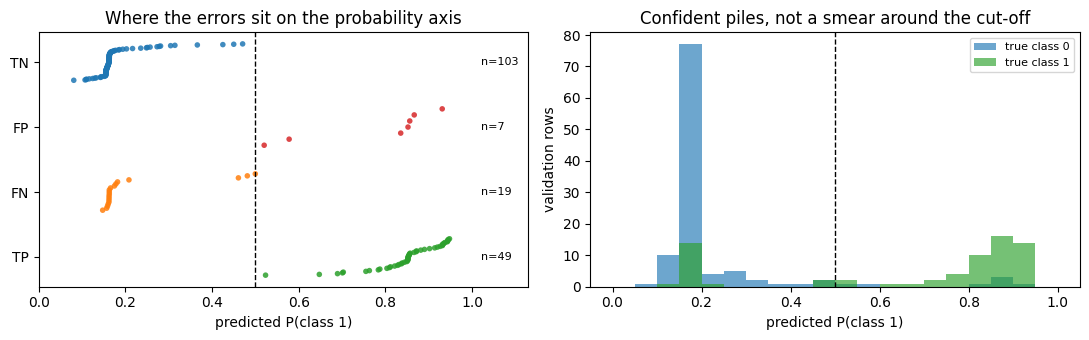

Rows the model was genuinely unsure about (0.40 <= p <= 0.60): 9 of 178
False negatives within 0.05 of the cut-off: 3  |  buried below 0.25: 16
False positives above 0.80 (confidently wrong): 5 of 7

Reading: the mistakes are CONFIDENT, not hesitant. Moving the cut-off can only
reach the 3 borderline miss(es); the 16 buried ones need better features
or more data, which is a different project task with a different cost.

(Bookkeeping: .predict() and the 0.5 probability cut-off agree on 177 of 178 rows. Part 4 explains why an SVM can disagree with itself here.)


In [7]:
# WHAT: the same 26 errors as above, placed on the probability axis instead of counted.
# WHY: "26 wrong" is a number; WHERE they sit tells you whether a threshold change can fix
# them. Errors hugging the cut-off are cheap to fix; errors deep in the wrong pile are not.
outcome = np.where((predictions == 1) & (y_val == 1), 'TP',
          np.where((predictions == 0) & (y_val == 0), 'TN',
          np.where((predictions == 1) & (y_val == 0), 'FP', 'FN')))
row_order = ['TP', 'FN', 'FP', 'TN']
row_color = {'TP': 'tab:green', 'TN': 'tab:blue', 'FP': 'tab:red', 'FN': 'tab:orange'}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# Panel 1: one dot per validation row. Sorted inside each band and spread deterministically
# (no jitter, so the picture is identical every run).
ax = axes[0]
for r, group in enumerate(row_order):
    idx = np.where(outcome == group)[0]
    p_sorted = np.sort(probs[idx])
    y_pos = r + np.linspace(-0.28, 0.28, len(p_sorted)) if len(p_sorted) > 1 else np.full(len(p_sorted), float(r))
    ax.scatter(p_sorted, y_pos, s=16, color=row_color[group], alpha=.85, edgecolors='none')
    ax.text(1.02, r, f'n={len(idx)}', va='center', fontsize=8)
ax.axvline(0.5, color='k', ls='--', lw=1)   # the default cut-off
# Note: the bands come from .predict(); the dashed line is the 0.5 probability cut-off.
# The agreement between the two is measured and printed under the figure.
ax.set_yticks(range(len(row_order))); ax.set_yticklabels(row_order)
ax.set_xlim(0, 1.13); ax.set_xlabel('predicted P(class 1)')
ax.set_title('Where the errors sit on the probability axis')

# Panel 2: the same probabilities, split by the TRUE label. Overlap = irreducible error:
# rows the model cannot separate no matter where the cut-off goes.
ax = axes[1]
bins = np.linspace(0, 1, 21)
ax.hist(probs[y_val == 0], bins=bins, alpha=.65, color='tab:blue', label='true class 0')
ax.hist(probs[y_val == 1], bins=bins, alpha=.65, color='tab:green', label='true class 1')
ax.axvline(0.5, color='k', ls='--', lw=1)
ax.set_xlabel('predicted P(class 1)'); ax.set_ylabel('validation rows')
ax.set_title('Confident piles, not a smear around the cut-off')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Read the figure in words — every number below is measured, not asserted.
unsure = int(((probs >= 0.4) & (probs <= 0.6)).sum())
fn_near = int((probs[false_negatives] >= 0.45).sum()) if len(false_negatives) else 0
fn_deep = int((probs[false_negatives] <= 0.25).sum()) if len(false_negatives) else 0
fp_deep = int((probs[false_positives] >= 0.80).sum()) if len(false_positives) else 0
print(f"Rows the model was genuinely unsure about (0.40 <= p <= 0.60): {unsure} of {len(y_val)}")
print(f"False negatives within 0.05 of the cut-off: {fn_near}  |  buried below 0.25: {fn_deep}")
print(f"False positives above 0.80 (confidently wrong): {fp_deep} of {len(false_positives)}")
print("\nReading: the mistakes are CONFIDENT, not hesitant. Moving the cut-off can only")
print(f"reach the {fn_near} borderline miss(es); the {fn_deep} buried ones need better features")
print("or more data, which is a different project task with a different cost.")

# The bands and the line come from two slightly different objects — check, don't assume.
agree = int((predictions == (probs >= 0.5).astype(int)).sum())
print(f"\n(Bookkeeping: .predict() and the 0.5 probability cut-off agree on {agree} of "
      f"{len(y_val)} rows. Part 4 explains why an SVM can disagree with itself here.)")

**Read the figure.** *Left:* every validation row is one dot, banded by outcome. The 19 false negatives do **not** crowd the dashed cut-off — 16 of them sit below p = 0.21, in the same stretch of the axis as the true negatives. Only 3 lie within 0.05 of the line. The 7 false positives mirror them: 5 sit above p = 0.80. *Right:* the same probabilities split by true label. Only 9 of the 178 rows land in the unsure band between 0.40 and 0.60.

So the model is not hesitating over these passengers — it is **confidently wrong** about a particular group of them. That is the finding to carry into Part 4: moving the cut-off can only reach the handful of errors sitting near the line. The 16 buried misses are a features-and-data problem, and no threshold touches them.

## Part 4: One Refinement Iteration — Decision Threshold Tuning

Evaluation is not the end: you act on it. The cheapest refinement is moving
the decision threshold: `predict_proba` gives a probability, and 0.5 is only
the *default* cut-off. We pick the threshold that maximizes F1 on the
validation set — still without touching the test set — and keep it only if it
actually helps.

In [8]:
# Refinement iteration: search the decision threshold that maximizes F1 on the
# validation set (a parameter of the DECISION, not of the trained model).
probs_val = results[best_model_name]['probabilities']

# Every candidate threshold comes from the precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_val, probs_val)
# F1 at each threshold (guard against 0/0 with a tiny denominator floor);
# the last precision/recall point has no threshold, so drop it
f1_scores = 2 * precisions * recalls / np.maximum(precisions + recalls, 1e-12)
best_idx = int(np.argmax(f1_scores[:-1]))
best_threshold = float(thresholds[best_idx])

# Compare the default 0.5 cut-off against the tuned one — both on validation
default_f1 = f1_score(y_val, (probs_val >= 0.5).astype(int))
tuned_f1 = f1_score(y_val, (probs_val >= best_threshold).astype(int))

print("=" * 60)
print("Refinement: decision-threshold tuning (validation set)")
print("=" * 60)
print(f"Best threshold found: {best_threshold:.3f}")
print(f"F1 at default 0.50 threshold: {default_f1:.4f}")
if abs(default_f1 - results[best_model_name]['f1']) > 1e-9:
    print(f"  (Note: Part 1 reported F1 {results[best_model_name]['f1']:.4f} for this model"
          " using .predict().")
    print("   For an SVM, .predict() follows the decision function while .predict_proba()"
          " is a")
    print("   separately calibrated estimate, so the two can disagree slightly. Everything"
          " below")
    print("   is computed from probabilities, which is what a threshold applies to.)")
print(f"F1 at tuned threshold:        {tuned_f1:.4f}")
print(f"Change: {tuned_f1 - default_f1:+.4f}")

# Keep the tuned threshold only if it genuinely helped on validation
chosen_threshold = best_threshold if tuned_f1 > default_f1 else 0.5
if chosen_threshold == 0.5:
    print("\nDecision: tuning did not beat the default — keep threshold 0.50")
else:
    print(f"\nDecision: adopt the tuned threshold {chosen_threshold:.3f} for the final evaluation")

Refinement: decision-threshold tuning (validation set)
Best threshold found: 0.461
F1 at default 0.50 threshold: 0.8000
  (Note: Part 1 reported F1 0.7903 for this model using .predict().
   For an SVM, .predict() follows the decision function while .predict_proba() is a
   separately calibrated estimate, so the two can disagree slightly. Everything below
   is computed from probabilities, which is what a threshold applies to.)
F1 at tuned threshold:        0.8125
Change: +0.0125

Decision: adopt the tuned threshold 0.461 for the final evaluation


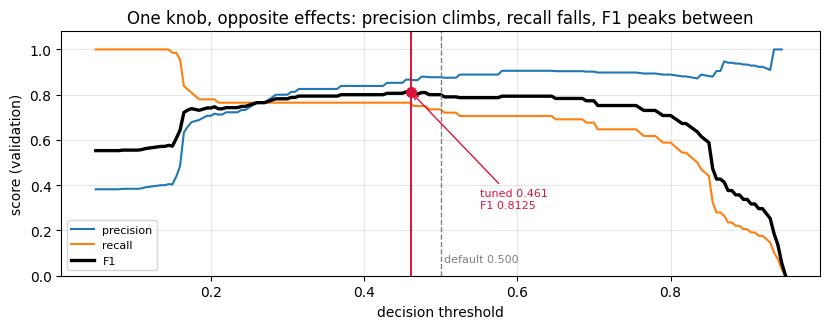

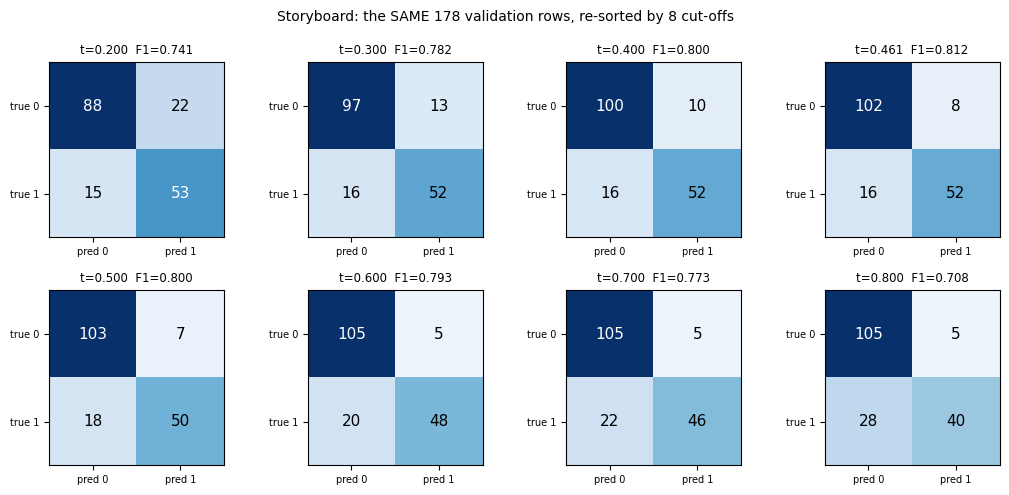

 threshold    TN    FP    FN    TP  precision   recall       F1
     0.200    88    22    15    53      0.707    0.779    0.741
     0.300    97    13    16    52      0.800    0.765    0.782
     0.400   100    10    16    52      0.839    0.765    0.800
     0.461   102     8    16    52      0.867    0.765    0.812  <- tuned
     0.500   103     7    18    50      0.877    0.735    0.800
     0.600   105     5    20    48      0.906    0.706    0.793
     0.700   105     5    22    46      0.902    0.676    0.773
     0.800   105     5    28    40      0.889    0.588    0.708


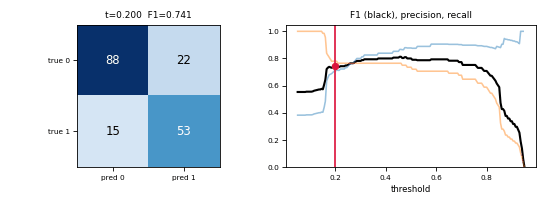

animation above: 8 frames, one per cut-off, same 178 rows throughout.

Peak validation F1 0.8125. 77 of the 181 cut-offs tested land
within 0.03 of it, from 0.30 to 0.68 — the peak is a PLATEAU,
and the +0.0125 this tuning bought is inside its width. Hold that thought
until the test set is opened in Part 5.


In [9]:
# WHAT: the threshold move above, as a process instead of a single before/after pair —
# the trade-off curves, a storyboard of the confusion matrix at eight cut-offs, a step
# table, and the same eight frames as an animation.
# WHY: threshold tuning is the one refinement in this notebook that is genuinely DYNAMIC:
# one knob slides, and the same 178 rows re-sort themselves between the four cells of the
# matrix. A pair of F1 numbers hides that; watching it happen makes the trade obvious.
# The GIF helper is the idiom from Course 09's course09_step_viz (frames_to_gif_bytes /
# display_gif), kept inline so this notebook stands alone.
import io
from PIL import Image
from IPython.display import Image as IPyImage, display

# Sweep the cut-off across the whole probability range and score each setting on validation.
sweep = np.linspace(0.05, 0.95, 181)
sweep_p, sweep_r, sweep_f1 = [], [], []
for t in sweep:
    yp = (probs_val >= t).astype(int)
    sweep_p.append(precision_score(y_val, yp, zero_division=0))
    sweep_r.append(recall_score(y_val, yp))
    sweep_f1.append(f1_score(y_val, yp))
sweep_p, sweep_r, sweep_f1 = np.array(sweep_p), np.array(sweep_r), np.array(sweep_f1)

# Above the highest predicted probability the model labels NOTHING positive, so precision
# is undefined (0/0), not zero. Mask those cut-offs so the blue line simply STOPS rather
# than diving to a value nobody measured — recall and F1 there are genuinely 0.
positives_predicted = np.array([(probs_val >= t).sum() for t in sweep])
sweep_p = np.where(positives_predicted > 0, sweep_p, np.nan)

# ── (a) the trade-off itself ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8.4, 3.4))
ax.plot(sweep, sweep_p, label='precision')
ax.plot(sweep, sweep_r, label='recall')
ax.plot(sweep, sweep_f1, label='F1', lw=2.4, color='k')
ax.axvline(0.5, ls='--', c='grey', lw=1)
ax.axvline(best_threshold, ls='-', c='crimson', lw=1.4)
ax.plot([best_threshold], [tuned_f1], 'o', color='crimson', ms=7)
ax.annotate(f'tuned {best_threshold:.3f}\nF1 {tuned_f1:.4f}', (best_threshold, tuned_f1),
            xytext=(best_threshold + 0.09, 0.30), fontsize=8, color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson'))
ax.text(0.505, 0.06, 'default 0.500', fontsize=8, color='grey')
ax.set_xlabel('decision threshold'); ax.set_ylabel('score (validation)')
ax.set_ylim(0, 1.08); ax.grid(alpha=.3); ax.legend(fontsize=8, loc='lower left')
ax.set_title('One knob, opposite effects: precision climbs, recall falls, F1 peaks between')
plt.tight_layout(); plt.show()

# ── the eight cut-offs the storyboard and the animation both use ─────────
fixed_steps = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
steps = sorted(set([round(float(chosen_threshold), 3)] + fixed_steps))[:8]

def draw_cm(ax, t):
    """One confusion matrix at threshold t, counts written into the cells."""
    yp = (probs_val >= t).astype(int)
    cm_t = confusion_matrix(y_val, yp)
    ax.imshow(cm_t, cmap='Blues', vmin=0, vmax=cm_t.max())
    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm_t[r, c], ha='center', va='center', fontsize=11,
                    color='white' if cm_t[r, c] > cm_t.max() * 0.6 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['pred 0', 'pred 1'], fontsize=7)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['true 0', 'true 1'], fontsize=7)
    ax.set_title(f't={t:.3f}  F1={f1_score(y_val, yp):.3f}', fontsize=8.5)
    return cm_t

# ── (b) storyboard: always renders, in the notebook and on paper ─────────
fig, axes = plt.subplots(2, 4, figsize=(10.5, 5.0))
flat = axes.ravel()
for a, t in zip(flat, steps):
    draw_cm(a, t)
for a in flat[len(steps):]:
    a.axis('off')
plt.suptitle(f'Storyboard: the SAME {len(y_val)} validation rows, re-sorted by {len(steps)} cut-offs',
             fontsize=10)
plt.tight_layout(); plt.show()

# ── the same sweep as a step table ───────────────────────────────────────
print(f"{'threshold':>10} {'TN':>5} {'FP':>5} {'FN':>5} {'TP':>5} {'precision':>10} {'recall':>8} {'F1':>8}")
for t in steps:
    yp = (probs_val >= t).astype(int)
    cm_t = confusion_matrix(y_val, yp)
    mark = '  <- tuned' if abs(t - chosen_threshold) < 1e-3 else ''
    print(f"{t:>10.3f} {cm_t[0,0]:>5d} {cm_t[0,1]:>5d} {cm_t[1,0]:>5d} {cm_t[1,1]:>5d} "
          f"{precision_score(y_val, yp, zero_division=0):>10.3f} {recall_score(y_val, yp):>8.3f} "
          f"{f1_score(y_val, yp):>8.3f}{mark}")

# ── (c) and as an animation: one frame per cut-off ───────────────────────
def frames_to_gif_bytes(frames, duration_ms=750):
    """Encode uint8 frames as one animated GIF (Course 09 course09_step_viz idiom)."""
    imgs = [Image.fromarray(np.asarray(f, dtype=np.uint8)) for f in frames]
    buf = io.BytesIO()
    imgs[0].save(buf, format="GIF", save_all=True, append_images=imgs[1:],
                 duration=duration_ms, loop=0)
    return buf.getvalue()

def display_gif(frames, duration_ms=750):
    display(IPyImage(data=frames_to_gif_bytes(frames, duration_ms), format="gif"))

def render_frame(t):
    """Matrix + a marker sliding along the F1 curve, rendered straight to a pixel array."""
    fig, ax = plt.subplots(1, 2, figsize=(7.2, 2.7), dpi=76)
    draw_cm(ax[0], t)
    ax[1].plot(sweep, sweep_f1, color='k', lw=2)
    ax[1].plot(sweep, sweep_p, alpha=.45); ax[1].plot(sweep, sweep_r, alpha=.45)
    yp = (probs_val >= t).astype(int)
    ax[1].axvline(t, color='crimson', lw=1.6)
    ax[1].plot([t], [f1_score(y_val, yp)], 'o', color='crimson', ms=6)
    ax[1].set_ylim(0, 1.05); ax[1].set_xlabel('threshold', fontsize=8)
    ax[1].set_title('F1 (black), precision, recall', fontsize=8.5)
    ax[1].tick_params(labelsize=7)
    fig.tight_layout(); fig.canvas.draw()
    arr = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
    plt.close(fig)
    return arr

display_gif([render_frame(t) for t in steps])
print(f"animation above: {len(steps)} frames, one per cut-off, same {len(y_val)} rows throughout.")

# Read the figure in words — measured from the sweep, not asserted.
peak = float(sweep_f1.max())
plateau = sweep[sweep_f1 >= peak - 0.03]
print(f"\nPeak validation F1 {peak:.4f}. {len(plateau)} of the {len(sweep)} cut-offs tested land")
print(f"within 0.03 of it, from {plateau.min():.2f} to {plateau.max():.2f} — the peak is a PLATEAU,")
print(f"and the {tuned_f1 - default_f1:+.4f} this tuning bought is inside its width. Hold that thought")
print("until the test set is opened in Part 5.")

**Read the storyboard and the animation.** One knob moves; the same 178 passengers re-sort themselves between four cells. Follow the bottom-left cell — the false negatives: it grows from **15 at t = 0.20 to 28 at t = 0.80**, while the top-right cell — the false positives — shrinks from **22 to 5**. Nothing is created or destroyed. Errors are *moved* from one column to the other, and the threshold decides which kind you would rather have.

Now compare only the two frames that matter. Going from the default **t = 0.500 (103 / 7 / 18 / 50)** to the tuned **t = 0.461 (102 / 8 / 16 / 52)** converts **2 false negatives into true positives and creates 1 extra false positive**. Three passengers change column. That is the entire +0.0125 of F1.

*(Flip back to the Part 2 heat map and you will find **103 / 7 / 19 / 49** at that same nominal 0.500 — one passenger's difference from the frame above. That is the SVM's `.predict()` decision function disagreeing with its separately calibrated `.predict_proba()`, the discrepancy the cell above printed a note about. Everything in Part 4 is computed from probabilities, because a threshold is something you apply to a probability.)*

And look at the black F1 curve: it is nearly flat across the middle of its range, so the gain sits *inside the width of its own plateau*. Part 5 measures whether three passengers' worth of tuning survives contact with data that did not choose it.

## Part 5: Final Evaluation on the Untouched Test Set

Every decision so far — which model, which threshold — used only training and
validation data. Now, **once**, we measure the finished system on the test
set. This is the number that goes in your report.

In [10]:
# The single final evaluation: apply the selected model + chosen threshold to
# the test set, which no decision so far has touched.
final_model = models[best_model_name]
probs_test = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (probs_test >= chosen_threshold).astype(int)

# Headline metrics on the untouched test set
print("=" * 60)
print(f"Final test evaluation: {best_model_name} @ threshold {chosen_threshold:.2f}")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred):.4f}")

# Apples-to-apples check: validation F1 at the SAME threshold vs test F1.
# A small gap means the validation estimate held up on unseen data.
val_f1_chosen = f1_score(y_val, (probs_val >= chosen_threshold).astype(int))
test_f1 = f1_score(y_test, y_test_pred)
gap = test_f1 - val_f1_chosen
print(f"\nValidation F1: {val_f1_chosen:.4f}  |  Test F1: {test_f1:.4f}  (gap {gap:+.4f})")

# Compute the interpretation from the gap instead of asserting it in prose
if abs(gap) < 0.03:
    print("Interpretation: test performance is close to validation — the estimate held up.")
elif gap < 0:
    print("Interpretation: test is noticeably below validation — our choices overfit the")
    print("validation set somewhat; report the test number, and do not re-tune on it.")
else:
    print("Interpretation: test came out above validation — likely sampling noise on")
    print("small splits; report the test number as-is.")

print("\n📝 This is the number that goes in your report — and the test set is now spent.")

Final test evaluation: SVM @ threshold 0.46
Accuracy:  0.8101
Precision: 0.8070
Recall:    0.6667
F1-Score:  0.7302

Validation F1: 0.8125  |  Test F1: 0.7302  (gap -0.0823)
Interpretation: test is noticeably below validation — our choices overfit the
validation set somewhat; report the test number, and do not re-tune on it.

📝 This is the number that goes in your report — and the test set is now spent.


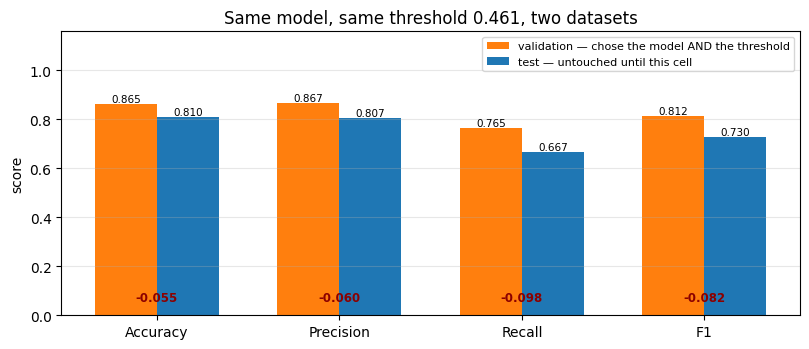

4 of 4 metrics are lower on test than on validation.
Largest drop: Recall (0.765 -> 0.667, -0.098).
Test set size: 179 rows, of which 69 are class 1 —
small enough that each single prediction moves recall by about 0.014.


In [11]:
# WHAT: the two rows of numbers just printed, drawn side by side.
# WHY: this gap is the whole lesson of the notebook, and it is much harder to argue with as
# a picture than as a sentence. NOTE: nothing new is measured here — the figure reuses
# y_test_pred from the cell above, so the test set is still opened exactly once.
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
y_val_pred_chosen = (probs_val >= chosen_threshold).astype(int)
val_scores = [accuracy_score(y_val, y_val_pred_chosen), precision_score(y_val, y_val_pred_chosen),
              recall_score(y_val, y_val_pred_chosen), f1_score(y_val, y_val_pred_chosen)]
test_scores = [accuracy_score(y_test, y_test_pred), precision_score(y_test, y_test_pred),
               recall_score(y_test, y_test_pred), f1_score(y_test, y_test_pred)]

x = np.arange(len(metric_labels)); bar_w = 0.34
fig, ax = plt.subplots(figsize=(8.2, 3.6))
b1 = ax.bar(x - bar_w/2, val_scores, bar_w, color='tab:orange',
            label='validation — chose the model AND the threshold')
b2 = ax.bar(x + bar_w/2, test_scores, bar_w, color='tab:blue',
            label='test — untouched until this cell')
ax.bar_label(b1, fmt='%.3f', fontsize=7.5); ax.bar_label(b2, fmt='%.3f', fontsize=7.5)
for i in range(len(metric_labels)):                       # the drop, written under each pair
    ax.annotate(f'{test_scores[i] - val_scores[i]:+.3f}', (x[i], 0.06), ha='center',
                fontsize=8.5, color='darkred', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metric_labels); ax.set_ylim(0, 1.16)
ax.set_ylabel('score'); ax.grid(axis='y', alpha=.3); ax.legend(fontsize=8, loc='upper right')
ax.set_title(f'Same model, same threshold {chosen_threshold:.3f}, two datasets')
plt.tight_layout(); plt.show()

# Read the figure in words — computed from the bars that were just drawn.
drops = [t - v for t, v in zip(test_scores, val_scores)]
worst = int(np.argmin(drops))
n_down = sum(1 for d in drops if d < 0)
print(f"{n_down} of {len(drops)} metrics are lower on test than on validation.")
print(f"Largest drop: {metric_labels[worst]} ({val_scores[worst]:.3f} -> {test_scores[worst]:.3f}, "
      f"{drops[worst]:+.3f}).")
print(f"Test set size: {len(y_test)} rows, of which {int(np.sum(y_test))} are class 1 —")
print("small enough that each single prediction moves recall by about "
      f"{1/max(int(np.sum(y_test)), 1):.3f}.")

**Read the figure.** All four bars are shorter on the right. The model is the same, the threshold is the same, the code is the same — only the data changed, from the 178 rows that made every decision to the 179 rows that made none.

**Recall falls furthest: 0.765 → 0.667, a drop of 0.098.** Recall is exactly what the threshold tuning in Part 4 was buying, so the refinement that looked like a gain on validation is the part that transferred worst. The table and the three sentences below say what to do about that.

### Reading the final number: an eight-point lesson in what a held-out set is for

The cell above printed the two numbers that matter more than any other pair in this course:

| | F1 |
|---|---|
| Validation, at the chosen threshold 0.461 | **0.8125** |
| Test — same model, same threshold | **0.7302** |
| Gap | **−0.0823** |

Nothing went wrong. There is no leakage bug and no coding error. The validation set was used to make **two** decisions — which of three models, and where to put the decision threshold — and each of those decisions bent slightly towards the particular 178 passengers in that split. The test set, which made none of your decisions, gives the honest estimate. That is the entire reason it existed.

Three sentences follow, and they are the three your gate-4 report needs:

1. **The number you report is 0.7302, not 0.8125.** Reporting the validation figure is not a rounding choice — it is reporting the score of a model that was partly fitted to the data it was scored on.
2. **You may not re-tune now.** The obvious next move — try another threshold, check the test set again — spends the test set a second time, and the third number would be *more* optimistic than the first, not less. The test set is spent.
3. **The gap is itself a finding.** *"Our validation estimate was optimistic by 8.2 points on 179 test rows"* tells a reader exactly how much to trust the rest of your report. Epic's 0.76–0.83 became 0.63 by the same mechanism, at a scale where it mattered immeasurably more.

### How much does that 0.7302 actually pin down?

One number, four decimal places, **179 rows**. Before it goes into a report, ask the
question an examiner will ask: what if the split had fallen differently — if those 20% had
caught 179 *other* passengers from the same manifest?

The bootstrap answers with the data already in hand. Resample the same 179 test rows with
replacement, thousands of times, and re-score each resample. **No model is refitted, no
threshold is re-chosen, and not one new prediction is made** — the test set is not opened a
second time. We are measuring how much the number we already have would wobble.

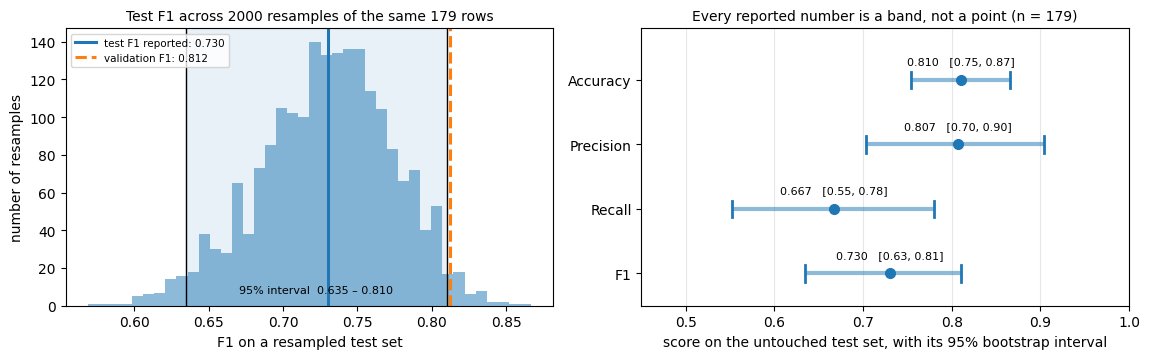

Reported test F1 0.7302   95% interval 0.6346 – 0.8102   (width 0.176, i.e. ±8.8 percentage points)
Reported accuracy 0.8101   95% interval 0.7542 – 0.8659   (±5.6 points)

Validation F1 0.8125 falls OUTSIDE the test interval; 2.2% of resamples scored at least that high.
Reading: report the band, not the point. The 95% interval on F1 is ±8.8 points,
wider than the 8.2-point validation-to-test gap that Part 5 called a finding.
Both statements hold, and both belong in the report: the validation estimate WAS
optimistic, and 179 rows still cannot pin the true score tighter than 0.63 to 0.81.


In [12]:
# WHAT: the single test score from Part 5, redrawn as the interval it actually is.
# WHY: "F1 = 0.7302" and "F1 = 0.73, 95% CI [.., ..], n = 179" are different promises, and
# only the second is honest about 179 rows. The ⚠️ section below claims that interval is
# about six points wide — this cell MEASURES the claim instead of asserting it.
# NOTE: the test set is not re-opened. y_test_pred was computed once, in Part 5; we only
# resample those existing predictions. Randomness IS the lesson here — the bootstrap's whole
# job is to imitate the sampling accident that handed us these particular 179 passengers.
rng = np.random.default_rng(42)          # fixed seed, so the figure is identical every run
N_BOOT = 2000
n_test = len(y_test)
ci_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
boot = {m: np.empty(N_BOOT) for m in ci_metrics}

for b in range(N_BOOT):
    idx = rng.integers(0, n_test, n_test)            # draw 179 rows WITH replacement
    yt, yp = y_test[idx], y_test_pred[idx]
    # The four metrics ARE the four confusion-matrix cells; computing them directly keeps
    # 2000 resamples fast enough for a live session.
    tp = int(((yt == 1) & (yp == 1)).sum()); fp = int(((yt == 0) & (yp == 1)).sum())
    fn = int(((yt == 1) & (yp == 0)).sum()); tn = int(((yt == 0) & (yp == 0)).sum())
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn) if tp + fn else 0.0
    boot['Accuracy'][b] = (tp + tn) / n_test
    boot['Precision'][b] = prec
    boot['Recall'][b] = rec
    boot['F1'][b] = 2 * prec * rec / (prec + rec) if prec + rec else 0.0

# Point estimates are exactly the ones already reported in Part 5 (sklearn, unresampled).
point_ci = {'Accuracy': accuracy_score(y_test, y_test_pred),
            'Precision': precision_score(y_test, y_test_pred),
            'Recall': recall_score(y_test, y_test_pred),
            'F1': f1_score(y_test, y_test_pred)}
ci = {m: np.percentile(boot[m], [2.5, 97.5]) for m in ci_metrics}

fig, axes = plt.subplots(1, 2, figsize=(11.6, 3.7))

# Panel 1: the whole bootstrap distribution of test F1, with the 95% band marked.
ax = axes[0]
lo, hi = ci['F1']
ax.hist(boot['F1'], bins=40, color='tab:blue', alpha=.5, edgecolor='none')
ax.axvspan(lo, hi, color='tab:blue', alpha=.10)
ax.axvline(lo, color='k', lw=1); ax.axvline(hi, color='k', lw=1)
ax.axvline(point_ci['F1'], color='tab:blue', lw=2.2,
           label=f"test F1 reported: {point_ci['F1']:.3f}")
ax.axvline(val_f1_chosen, color='tab:orange', lw=2.2, ls='--',
           label=f"validation F1: {val_f1_chosen:.3f}")
ax.set_title(f'Test F1 across {N_BOOT} resamples of the same {n_test} rows', fontsize=10)
ax.set_xlabel('F1 on a resampled test set'); ax.set_ylabel('number of resamples')
ax.legend(fontsize=7.5, loc='upper left')
ax.text((lo + hi) / 2, ax.get_ylim()[1] * 0.045,
        f'95% interval  {lo:.3f} – {hi:.3f}', ha='center', fontsize=8)

# Panel 2: the same treatment for all four reported numbers.
ax = axes[1]
ypos = np.arange(len(ci_metrics))[::-1]
for yv, m in zip(ypos, ci_metrics):
    l, h = ci[m]
    ax.plot([l, h], [yv, yv], color='tab:blue', lw=3, alpha=.5, solid_capstyle='butt')
    ax.plot([l, l], [yv - .13, yv + .13], color='tab:blue', lw=2)
    ax.plot([h, h], [yv - .13, yv + .13], color='tab:blue', lw=2)
    ax.plot([point_ci[m]], [yv], 'o', color='tab:blue', ms=7)
    ax.text(point_ci[m], yv + 0.24, f'{point_ci[m]:.3f}   [{l:.2f}, {h:.2f}]',
            ha='center', fontsize=8)
ax.set_yticks(ypos); ax.set_yticklabels(ci_metrics)
ax.set_ylim(-0.5, len(ci_metrics) - 0.5 + 0.30)
ax.set_xlim(0.45, 1.0)
ax.set_xlabel('score on the untouched test set, with its 95% bootstrap interval')
ax.set_title(f'Every reported number is a band, not a point (n = {n_test})', fontsize=10)
ax.grid(axis='x', alpha=.3)
plt.tight_layout(); plt.show()

# Read the figure in words — measured from the bootstrap, not asserted.
width = hi - lo
print(f"Reported test F1 {point_ci['F1']:.4f}   95% interval {lo:.4f} – {hi:.4f}"
      f"   (width {width:.3f}, i.e. ±{width / 2 * 100:.1f} percentage points)")
acc_lo, acc_hi = ci['Accuracy']
print(f"Reported accuracy {point_ci['Accuracy']:.4f}   95% interval {acc_lo:.4f} – {acc_hi:.4f}"
      f"   (±{(acc_hi - acc_lo) / 2 * 100:.1f} points)")
inside = lo <= val_f1_chosen <= hi
share = float((boot['F1'] >= val_f1_chosen).mean())
print(f"\nValidation F1 {val_f1_chosen:.4f} falls "
      f"{'INSIDE' if inside else 'OUTSIDE'} the test interval; "
      f"{share * 100:.1f}% of resamples scored at least that high.")
half_pts = width / 2 * 100
gap_pts = (val_f1_chosen - point_ci['F1']) * 100
print(f"Reading: report the band, not the point. The 95% interval on F1 is ±{half_pts:.1f} points,")
print(f"{'wider' if half_pts > gap_pts else 'narrower'} than the {gap_pts:.1f}-point validation-to-test"
      " gap that Part 5 called a finding.")
print("Both statements hold, and both belong in the report: the validation estimate WAS")
print(f"optimistic, and {n_test} rows still cannot pin the true score tighter than"
      f" {lo:.2f} to {hi:.2f}.")

**Read the figure.** *Left:* the same 179 test rows, resampled 2 000 times with replacement. The reported F1 (solid blue, **0.730**) sits inside a spread running from 0.57 to 0.87, and the two black lines cut off the middle 95% at **0.635 and 0.810**. That band is **±8.8 percentage points** wide — which is what "0.7302" actually means on 179 rows. *Right:* the other three reported numbers carry bands of their own. Recall's is the widest, **0.55 to 0.78**, because recall is computed from the **69 survivors** in the test set alone — the model found 46 of them — and 69 rows resolve very little.

The orange dashed line is the validation F1, **0.812**. It falls **just outside** the top of the test interval, and only **2.2%** of the resamples reached it: the validation number really was flattering, exactly as Part 5 said. But the width is the second lesson and the harder one. The sentence your gate-4 report needs is not *"F1 = 0.7302"* — it is *"F1 = 0.73, 95% CI [0.63, 0.81], n = 179"*. And the ⚠️ bullet below, which estimates the accuracy interval at about ±6 points, is confirmed here by measurement at **±5.6**.

## 💬 Discuss

No single right answer. Argue from the numbers this notebook printed, and say what would change your mind.

1. **Which error is worse here — and who is entitled to decide?** On validation the selected model produced **7 false positives and 19 false negatives**, and the false negatives carried an average predicted probability of **0.2166**: the model was *confidently* wrong about them. Tuning moved the threshold from 0.500 to 0.461, buying recall with precision. For a survival-risk score used to prioritise a rescue, are 19 missed survivors worse than 7 false alarms? Now answer the same question for the Epic sepsis model, where the trade runs between a missed sepsis case and an alert on 18% of admissions that clinicians will eventually learn to ignore. Does the arithmetic change, or only the stakes — and if only the stakes, who should be setting the threshold?
2. **Is it ready?** Test F1 is **0.7302**; the majority-class baseline scores 0.6180 accuracy and **F1 0.0000** — it never identifies a single survivor. You have comfortably beaten the baseline. Write the three sentences you would say to a client who asks whether the system is ready. **One of them must contain a number you are not proud of.** Which one is it, and what happens to your credibility if you leave it out and the client finds it later?
3. **What would overturn the model choice?** The SVM won on validation F1 (**0.7903**) ahead of the random forest (**0.7612**) and logistic regression (**0.7176**). All three were fitted once, on one split, with one seed. Propose a specific, cheap experiment that would confirm or overturn that ranking — and state, *before* running it, the result that would make you switch. If you cannot name that result in advance, you are not running an experiment; you are looking for agreement.

## ⚠️ Where this breaks

This is the most disciplined workflow in the course, and it still has edges. Naming them **is** the limitations section your gate-4 report needs.

- **179 test rows cannot carry a confident claim.** One prediction is worth 0.56%, and the bootstrap cell above measures what that costs: accuracy **0.810 with a 95% interval of 0.754–0.866 (±5.6 points)**, F1 **0.730 with 0.635–0.810 (±8.8 points)**. So "our model reaches 81% accuracy" honestly means "somewhere between the mid-70s and the high-80s". Report an interval, or report the number with its sample size attached — never the bare number. The AIAT 113 U5 notebook linked at the top does the same job analytically.
- **The test set is spent, and it does not refill.** Every subsequent look at it — a new threshold, one more feature, "just checking" — makes the reported number more optimistic than the truth. If you need another iteration you need new data, not another look. **The cheaper alternative when data is scarce:** nested cross-validation, which gives an honest estimate without a permanent hold-out, at the cost of more compute and a harder story to tell an examiner.
- **Every metric here assumes the test set looks like the future.** Accuracy, precision, recall, F1 and AUC are all computed on rows drawn from the same file as the training rows. Epic's model met a different hospital; Google's retinopathy system met a different camera and a different room. **The assumption that must hold is that your deployment distribution equals your test distribution.** It usually holds for a graduation project and almost never holds for a deployed one — which is exactly why AIAT 125 U5 teaches drift detection.
- **An aggregate metric hides *whose* errors these are.** The failure analysis above splits errors into false positives and false negatives; it does not split them by person. A model can score 0.73 overall and 0.45 for one subgroup, and nothing printed in this notebook would reveal it. Slice your metrics by every attribute that identifies a group of people before you write the report — the technique is in AIAT 116 U2, and on this dataset the obvious slice is `Sex`, which the Unit 2 lesson already showed carries a 74.2% / 18.9% survival gap.
- **Threshold tuning is a policy decision wearing a hyperparameter's clothes.** Moving 0.500 → 0.461 changed *who* gets predicted positive. Here it is +0.0125 of F1 in a graded exercise. In a hiring, lending or clinical system it is a policy, and it belongs to whoever is accountable for the consequences — not to `argmax` on an F1 curve.
- **When NOT to use this workflow.** Below roughly a thousand rows, a single 60/20/20 split is too noisy to support the comparisons made here: use repeated cross-validation and report the spread instead. And when the classes are severely imbalanced — the credit-card fraud file used in Unit 2 has **492 frauds in 284,807 rows, 0.17%** — accuracy is meaningless and even F1 can mislead. Use precision-recall AUC, and report the operating point you would actually run at.

## Summary

### Key Evaluation Steps:
1. **Three-way split first**: train to fit, validation to compare and refine, test for one final measurement
2. **Multiple Algorithms**: compare candidates on the validation set and select by one agreed metric
3. **Comprehensive Metrics**: accuracy, precision, recall, F1, ROC-AUC
4. **Visualization**: confusion-matrix heat map, ROC curves, precision-recall curve, the three candidates on one axis, the errors placed on the probability axis, the threshold sweep as a storyboard plus animation, the validation-vs-test bars, and the bootstrap interval behind the final number (all rendered above)
5. **Failure Analysis**: break errors into FP/FN and inspect the model's confidence on each
6. **One refinement iteration**: decision-threshold tuning on validation, kept only if it helped
7. **Final test evaluation**: the test set is used exactly once, and its number is what you report
8. **Report the interval, not the point**: a bootstrap on the predictions you already made turns one number into the band it always was

### Optimization Strategies (for your own project):
- **Data**: collect more data, improve data quality, feature engineering
- **Model**: try different architectures, ensemble methods
- **Hyperparameters**: optimize with the CV-based searches from Unit 3
- **Thresholds**: adjust decision thresholds for the precision/recall trade-off (demonstrated above)

### Running this on your own project data
Save your dataset as `data/my_project_data.csv`, set `TARGET` in the loading cell to your
label column, and re-run. Every metric, figure and computed interpretation adapts — and the
test-set discipline stays the same.

**Reference:** Course 12, Unit 4: "Evaluation and Refinement" — reuse the evaluation
workflow above on your capstone project.

---

## 🔭 State of the field (2026)

This notebook fits a deterministic classifier, predicts once, and bootstraps the predictions it already
made — and for a scikit-learn model that is the complete and correct answer. Many 2026 graduation projects
instead evaluate a **stochastic** system: an LLM or a tool-using agent that answers the same input differently
on the next run, so a single run's score is itself a draw rather than a measurement. Practice has therefore
moved to reporting repeated runs — **pass@1 next to pass^k**, the fraction of tasks solved on *every* one of
k attempts. On a 2026 stateful-workflow agent benchmark the strongest system reached **65.36% pass@1 but only
25.25% pass^20** (Li et al. 2026): roughly three in five of its single-run successes did not survive being
asked twenty times. The accompanying 2026 argument is that *reliability*, not peak capability, is now the binding
constraint — it comes with a vocabulary (consistency, robustness, predictability, safety) and with the finding
that recent capability gains bought only small reliability gains (Rabanser et al. 2026). And where the grader
is itself a model, that judge's own error rates must be corrected for before any interval around its verdict
means anything (Lee et al. 2025).

**Why this lesson is still the right thing to learn.** pass^k is the repeated-run form of exactly the argument
Part 5's bootstrap cell already makes: one score on a finite sample is a draw, so report the band it came from.
The three-way split, spending the test set once, and attaching an interval to the headline number are the
mechanism every one of those newer protocols is built out of — and they are what Unit 4, *Evaluation and
Refinement*, examines. Carry one extra rule into your own project: **if any part of your system is stochastic,
run the whole evaluation k times and report the spread**, the same way the bootstrap cell reports it here.

## 📚 References

1. Fawcett, T. (2006). *An introduction to ROC analysis*. Pattern Recognition Letters, 27(8), 861–874. <https://doi.org/10.1016/j.patrec.2005.10.010>
2. Raschka, S. (2018). *Model Evaluation, Model Selection, and Algorithm Selection in Machine Learning*. arXiv. <https://arxiv.org/abs/1811.12808>
3. D'Amour, A., Heller, K., Moldovan, D., et al. (2020). *Underspecification Presents Challenges for Credibility in Modern Machine Learning*. arXiv. <https://arxiv.org/abs/2011.03395>
4. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 5: Resampling Methods. Springer.

**Cases cited in this lesson**

5. Wong, A., Otles, E., Donnelly, J. P., et al. (2021). *External Validation of a Widely Implemented Proprietary Sepsis Prediction Model in Hospitalized Patients*. **JAMA Internal Medicine, 181(8), 1065–1070.** <https://doi.org/10.1001/jamainternmed.2021.2626> — 27,697 patients, 38,455 hospitalizations; measured AUC 0.63 against a vendor-reported 0.76–0.83; 67% of sepsis patients missed at the operating threshold, alerts on 18% of hospitalizations.

**Recent work (2025–2026)**

6. Rabanser, S., Kapoor, S., Kirgis, P., Liu, K., Utpala, S., & Narayanan, A. (2026). *Towards a Science of AI Agent Reliability*. arXiv. <https://arxiv.org/abs/2602.16666> — twelve metrics across consistency, robustness, predictability and safety; reports that recent capability gains yielded only small reliability gains.
7. Li, Z., Ko, Y., Keramati, A., et al. (2026). *One Success Isn't Reliability: Thinkingbox, a Sandbox and Benchmark for Agents in Stateful Business Workflows*. arXiv. <https://arxiv.org/abs/2608.19741> — the pass@1 / pass^k gap measured directly: 65.36% pass@1 against 25.25% pass^20 for the strongest system tested.
8. Lee, C., Zeng, T., Jeong, J., Sohn, J.-y., & Lee, K. (2025). *How to Correctly Report LLM-as-a-Judge Evaluations*. arXiv. <https://arxiv.org/abs/2511.21140> — corrects for a judge model's own sensitivity and specificity, and gives calibrated confidence intervals for judge-based scores.